In [19]:
import pandas as pd
import pathlib
import rootutils
import torch
import tqdm
import numpy as np
import seaborn as sns

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from torch.nn import functional as F
from matplotlib import pyplot as plt

from src.core.data.sounding_out_chorus import SoundingOutChorus
from src.core.data.soundscape_embeddings import SoundscapeEmbeddingsDataModule
from src.core.transforms.translation import translation_1d as translation
from src.core.models.sivae import SIVAE
from src.core.models.vae import VAE
from src.core.models import SpeciesDetector
from src.core.utils.sketch import make_ax_invisible

model_path = pathlib.Path("/its/home/kag25/models/v3")

In [91]:
data = SoundingOutChorus("/its/home/kag25/data/sounding_out")

species_params = [ 
    # { "species_name": "Sylvia atricapilla_Eurasian Blackcap", "file_name": "PL-11_0_20150603_0645.wav", "t_start_seconds": 19, "delta": 30,  },
    { "species_name": "Turdus merula_Eurasian Blackbird", "file_name": "train/data/PL-12_0_20150604_0345.wav", "t_start_seconds": 4.3, "delta": 8, "shift": -1.0 },  
    { "species_name": "Erithacus rubecula_European Robin", "file_name": "train/data/BA-04_0_20150620_0515.wav", "t_start_seconds": 29, "delta": 12, "shift": -0.5 },  
    { "species_name": "Phasianus colchicus_Ring-necked Pheasant", "file_name": "train/data/PL-03_0_20150605_0445.wav", "t_start_seconds": 29.5, "delta": 10, "shift": -1.0 },  
    { "species_name": "Troglodytes hiemalis_Winter Wren", "file_name": "train/data/PL-11_0_20150605_0500.wav", "t_start_seconds": 45.2, "delta": 10, "shift": 0.0 },  
    { "species_name": "Cyanistes caeruleus_Eurasian Blue Tit", "file_name": "train/data/PL-12_0_20150604_0345.wav", "t_start_seconds": 47,"delta": 10, "shift": -0.5 },  
    { "species_name": "Columba palumbus_Common Wood-Pigeon", "file_name": "train/data/BA-04_0_20150620_0615.wav", "t_start_seconds": 24.2,  "delta": 10, "shift": -0.5 },  
    { "species_name": "Corvus corone_Carrion Crow", "file_name": "train/data/BA-01_0_20150621_0445.wav", "t_start_seconds": 32.6, "delta": 20, "shift": 0.5  }
]
for params in species_params:
    counts = data.metadata.merge(
        data.labels.astype(bool).astype(int),
        left_index=True,
        right_index=True
    ).groupby("habitat")[params["species_name"]].sum().reset_index()
    params["habitat"] = counts.loc[counts[params["species_name"]].idxmax()].habitat


In [32]:
# vae = VAE.load_from_checkpoint(model_path / "vae" / "silly-byte" / "step=180000.ckpt", map_location="cuda").eval()
sivae = SIVAE.load_from_checkpoint(model_path / "sivae" / "wanted-pencil" / "step=180000.ckpt", map_location="cuda").eval()
clf = SpeciesDetector.load_from_checkpoint(model_path / "species_detectors" / "wanted-pencil_SO_UK.ckpt", map_location="cuda").eval()
clf = dict(zip(clf.classifiers.keys(), map(lambda layer: layer.weight, clf.classifiers.values())))

INFO:src.core.models.sivae:Freezing alignment encoder


In [41]:
dm = SoundscapeEmbeddingsDataModule(root="/its/home/kag25/data/soundscape_vae_embeddings/wanted-pencil/SO_UK").setup()
embeddings = dm.train_data
features = embeddings.features
labels = embeddings.labels.reset_index()
labels = labels.merge(data.metadata.loc[data.metadata.index.isin(labels.file_i), ["file_name", "habitat"]], on='file_i', how="inner")
# encode the habitat mean representation for this model
z_mean = embeddings.features[[f"z_mean_{i}" for i in range(128)]].merge(labels[["file_i", "habitat"]], on="file_i", how="left").drop("file_i", axis=1).groupby("habitat").mean()
habitat_means = {
    habitat: torch.tensor(z_mean.loc[habitat], dtype=torch.float32, device="cuda").unsqueeze(0).unsqueeze(0)
    for habitat in z_mean.index
}

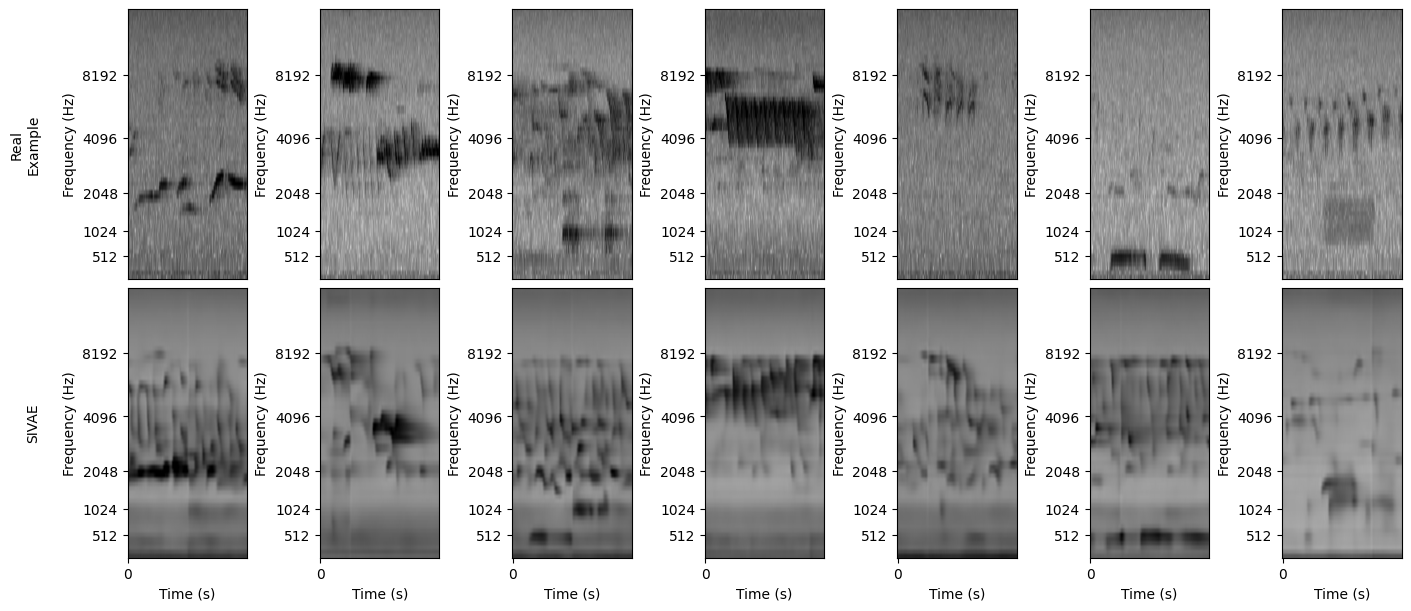

In [92]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=len(species_params) + 1,
    figsize=(2 * len(species_params), 6),
    width_ratios=[0.01, *[0.95 / (len(species_params)) for _ in range(len(species_params))]],
    constrained_layout=True,
)
vmax, vmin = 0.0, -80
hops_per_second = 48_000 / 384
frame_length_seconds = 192 / hops_per_second
frame_length_hops = 192

with torch.no_grad():
    for i, params in enumerate(species_params):
        species_name, file_name, t_start_seconds, delta, shift, habitat = params.values()
        if i == 0:
            title_ax = axes[0, 0]
            title_ax.set_ylabel("Real\nExample")
            make_ax_invisible(title_ax)
            title_ax = axes[1, 0]
            title_ax.set_ylabel("SIVAE")
            make_ax_invisible(title_ax)

        ax = axes[0, i + 1]
        t_start = int(t_start_seconds * hops_per_second)
        t_end = t_start + int(frame_length_seconds * hops_per_second)
        x = sivae.front_end(data.load_sample(data.base_dir / file_name).unsqueeze(0).to("cuda")).squeeze()
        x_db = 20 * np.log10(x[:, t_start:t_end].exp().cpu())
        # plot the original
        vae.front_end.plot(x_db, vmax=vmax, vmin=vmin, ax=ax, cmap="Greys")
        ax.set_xticks([0, 191], [0.0, 1.536], rotation=90)
        ax.tick_params(labelbottom=False, bottom=False)
        ax.set_xlabel("")

        z = habitat_means[habitat]
        W = clf[species_name]
        norm = torch.linalg.norm(W)
        z_tilde = z + ((z @ W.T / norm) + delta) * (W / norm)
        x_tilde = sivae.decode(z_tilde, shift * torch.ones(1, 1, 1, device=z.device)).cpu().squeeze().t()
        x_tilde_db = 20 * np.log10(x_tilde.exp())
        ax = axes[1, i + 1]
        sivae.front_end.plot(x_tilde_db, vmax=vmax, vmin=vmin, cmap="Greys", ax=ax)

plt.show()